# 08 · Brain visualization

How do you put a per-parcel prediction score onto a brain? This notebook shows
the visualization path: one score per Schaefer parcel -> grouped by 7 networks
-> rendered on the cortical surface. The scores here are an **illustrative
pattern** (visual cortex elevated) chosen so the mapping is easy to read; for a
**real** scored prediction from a real model, see notebook 10.

`prediction r`: 0 = no prediction, ~0.5 = strong (the same scale as notebook 10).

## Per-parcel scores, grouped by network

One illustrative score per Schaefer parcel, using the real 1000-parcel network
assignments. The values are hand-set (visual network elevated) to make the
visualization legible -- this is not a scored result; notebook 10 is.

In [1]:
import numpy as np

# Illustrative demo. The parcel-to-network assignments are real (Schaefer's 1000-parcel
# atlas), but the scores are hand-set so the picture is easy to read -- this is NOT a
# scored model. Notebook 10 runs the same drawing path with real scores.
SCHAEFER_7NETWORKS = ['Vis', 'SomMot', 'DorsAttn', 'SalVentAttn', 'Limbic', 'Cont', 'Default']
# A parcel is one small patch of cortex; this file says which network each patch belongs to.
net_idx = np.load('assets/schaefer1000_networks.npy')     # per-parcel network (0..6)

# Give visual cortex the highest values and everywhere else low, plus a little noise so
# the map does not look artificially flat.
rng = np.random.RandomState(0)
base = np.array([0.45, 0.20, 0.15, 0.12, 0.08, 0.15, 0.10])   # one value per network
per_parcel_r = np.clip(base[net_idx] + rng.randn(len(net_idx)) * 0.05, 0, 1)

# Average within each network, to check the pattern came out as intended.
for n, name in enumerate(SCHAEFER_7NETWORKS):
    print(f'{name:12s} mean r = {per_parcel_r[net_idx==n].mean():.3f}  ({(net_idx==n).sum()} parcels)')

Vis          mean r = 0.445  (162 parcels)
SomMot       mean r = 0.201  (194 parcels)
DorsAttn     mean r = 0.143  (122 parcels)
SalVentAttn  mean r = 0.115  (121 parcels)
Limbic       mean r = 0.086  (60 parcels)
Cont         mean r = 0.140  (129 parcels)
Default      mean r = 0.104  (212 parcels)


## Network means

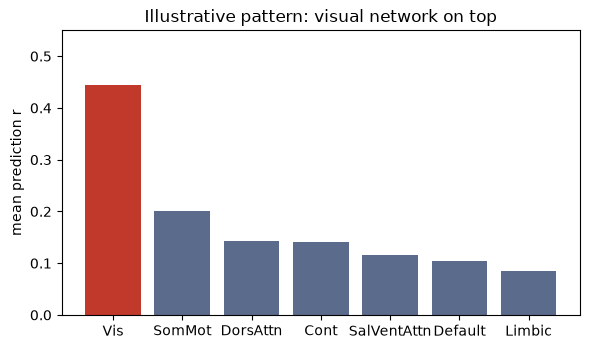

In [2]:
import matplotlib.pyplot as plt

# Collapse to one mean r per network, sorted high-to-low so the ranking is visible.
means = [per_parcel_r[net_idx == n].mean() for n in range(7)]
order = np.argsort(means)[::-1]
# Bar chart with the visual network highlighted -- illustrative pattern, visual elevated, not a scored result.
fig, ax = plt.subplots(figsize=(6, 3.6))
bars = ax.bar([SCHAEFER_7NETWORKS[i] for i in order], [means[i] for i in order],
              color=['#c0392b' if SCHAEFER_7NETWORKS[i] == 'Vis' else '#5a6b8c' for i in order])
ax.set_ylabel('mean prediction r'); ax.set_ylim(0, 0.55)
ax.set_title('Illustrative pattern: visual network on top')
fig.tight_layout(); plt.show()

## The same pattern on the cortex

A cortical-surface render (real renderer, real Schaefer anatomy) of a per-parcel
map, with the **occipital pole** -- visual cortex, at the back of the brain --
hottest and the rest of cortex cool. Same story as the bars above, shown on
anatomy.

![cortex](assets/cortex_visual_prediction.png)

The live inflated-surface renderer is `brainscore.visualization.cortical_surface_map`
(needs `nilearn`); the image above is its committed output. The point here is the
visualization path itself -- notebook 10 supplies a real model's scores to feed
through it.

**Reading it:** each parcel gets one score; grouping by network puts the visual
network on top, and the surface lights up visual cortex. That is the *expected*
shape for a vision model and what this visualization is built to reveal -- a
model with no region-specific structure would give a flat bar and a uniform
surface. Notebook 10 runs this with a real model's scores.